In [2]:
import pandas as pd

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [8]:
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
 
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [12]:
RANDOM_STATE = 42

#Create functions that put our dollars in billions and millions
def billions(x, pos):
    return f'${x/1e9:,.1f}B'
def millions(x, pos):
    return f'${x/1e6:,.0f}M'

In [3]:
df = pd.read_csv('quarterly_retail_sales_tax_data_by_county_and_city_993_rows.csv')

In [4]:
df.head(5)

,fiscal_year,quarter_ending_date,county_fips_code,county_name,city_name,number_of_returns,taxable_sales,computed_tax,percent_of_tax
0,2012,12/31/2011,19001,Adair,Adair,69,2685816,159462,0.0003
1,2012,9/30/2011,19001,Adair,Adair,58,3113359,184309,0.0004
2,2012,3/31/2012,19001,Adair,Adair,61,2467274,146944,0.0003
3,2012,6/30/2012,19001,Adair,Adair,57,3036969,180138,0.0003
4,2012,3/31/2012,19001,Adair,Bridgewater,11,325511,19531,0.0000


In [5]:
#Get a list of the mostly urban counties and convert into the file
urban_counties = ['Polk', 'Linn', 'Scott', 'Black Hawk', 'Johnson', 
                   'Pottawattamie', 'Dubuque', 'Woodbury']

df['county_type'] = df['county_name'].apply(
    lambda x: 'Urban' if x in urban_counties else 'Rural'
)

In [13]:
df['quarter_ending_date'] = pd.to_datetime(df['quarter_ending_date'])
df = df.sort_values('quarter_ending_date').reset_index(drop=True)

In [15]:
df['calendar_year'] = df['quarter_ending_date'].dt.year
df['calendar_quarter'] = df['quarter_ending_date'].dt.quarter

In [16]:
df.head(5)

,fiscal_year,quarter_ending_date,county_fips_code,county_name,city_name,number_of_returns,taxable_sales,computed_tax,percent_of_tax,county_type,calendar_year,calendar_quarter
0,2012,2011-09-30,19143,Osceola,Melvin,12,1956527,117392,0.00,Rural,2011,3
1,2012,2011-09-30,19131,Mitchell,Riceville,26,843842,50631,0.00,Rural,2011,3
2,2012,2011-09-30,19047,Crawford,Westside,17,456763,27406,0.00,Rural,2011,3
3,2012,2011-09-30,19131,Mitchell,Other,21,307277,18437,0.00,Rural,2011,3
4,2012,2011-09-30,19049,Dallas,Adel,210,12179501,729478,0.00,Rural,2011,3


In [22]:
# Derived financial metrics
df['avg_sale_per_return'] = df['taxable_sales'] / df['number_of_returns'].replace(0, np.nan) #Get the averages and rates
df['effective_tax_rate'] = df['computed_tax'] / df['taxable_sales'].replace(0, np.nan)

In [23]:
print(f"Shape: {df.shape}")
print(f"Date range: {df.quarter_ending_date.min().date()} to {df.quarter_ending_date.max().date()}")
print(f"Counties: {df.county_name.nunique()} | Cities: {df.city_name.nunique()}")
print(f"\\nMissing values:\\n{df.isnull().sum()}")

Shape: (48074, 14)
Date range: 2011-09-30 to 2025-12-31
Counties: 99 | Cities: 844
\nMissing values:\nfiscal_year             0
quarter_ending_date     0
county_fips_code        0
county_name             0
city_name               0
number_of_returns       0
taxable_sales           0
computed_tax            0
percent_of_tax          0
county_type             0
calendar_year           0
calendar_quarter        0
avg_sale_per_return     0
effective_tax_rate     48
dtype: int64


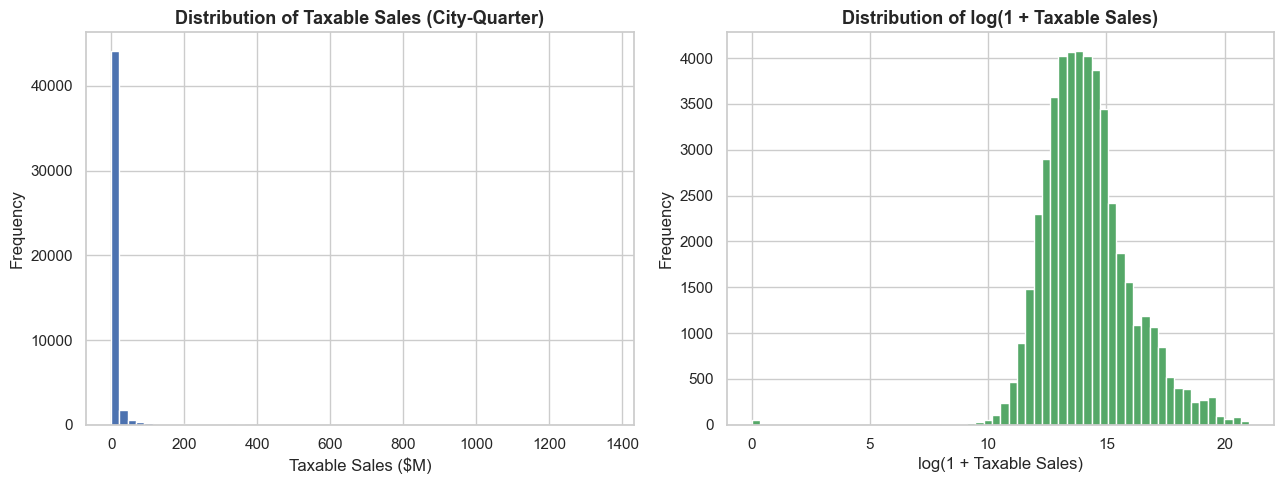

In [25]:
#EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['taxable_sales']/1e6, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of Taxable Sales (City-Quarter)')
axes[0].set_xlabel('Taxable Sales ($M)')
axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(df['taxable_sales']), bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('Distribution of log(1 + Taxable Sales)')
axes[1].set_xlabel('log(1 + Taxable Sales)')
axes[1].set_ylabel('Frequency')
 
plt.tight_layout()
plt.show()

In [26]:
print(f"Skewness (raw): {df['taxable_sales'].skew():.2f}")
print(f"Skewness (log1p): {np.log1p(df['taxable_sales']).skew():.2f}")

Skewness (raw): 11.23
Skewness (log1p): 0.20


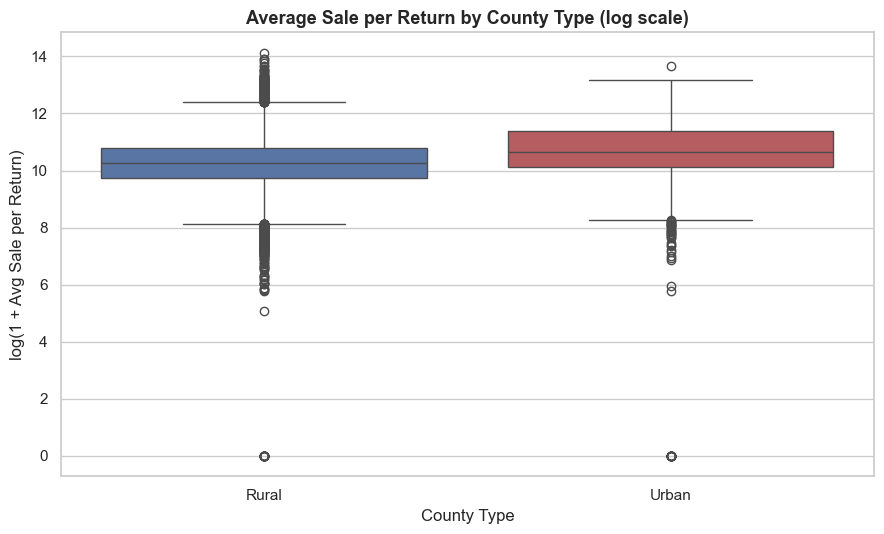

In [27]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x='county_type', y=np.log1p(df['avg_sale_per_return']), ax=ax,
            palette={'Urban': '#C44E52', 'Rural': '#4C72B0'})
ax.set_title('Average Sale per Return by County Type (log scale)')
ax.set_xlabel('County Type')
ax.set_ylabel('log(1 + Avg Sale per Return)')
plt.tight_layout()
plt.show()

In [28]:
state_trend = df.groupby('quarter_ending_date')['taxable_sales'].sum().reset_index()

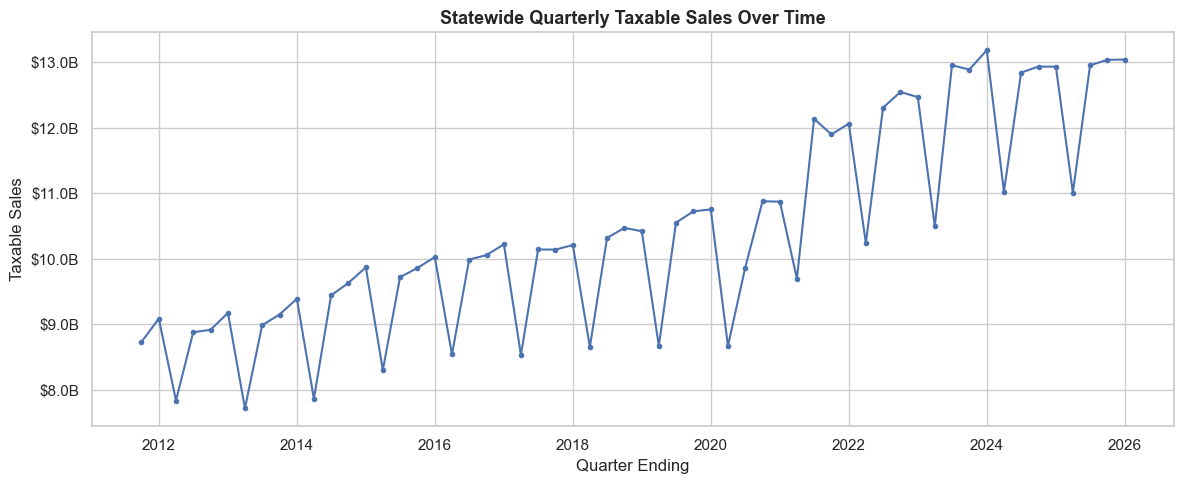

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(state_trend['quarter_ending_date'], state_trend['taxable_sales'], marker='o', markersize=3,
        color='#4C72B0', linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(billions))
ax.set_title('Statewide Quarterly Taxable Sales Over Time')
ax.set_xlabel('Quarter Ending')
ax.set_ylabel('Taxable Sales')
plt.tight_layout()
plt.show()

In [30]:
corr_cols = ['number_of_returns','taxable_sales','computed_tax','avg_sale_per_return','effective_tax_rate']
corr = df[corr_cols].corr(method='spearman')
corr

,number_of_returns,taxable_sales,computed_tax,avg_sale_per_return,effective_tax_rate
number_of_returns,1.00,0.88,0.88,0.49,-0.44
taxable_sales,0.88,1.00,1.00,0.83,-0.44
computed_tax,0.88,1.00,1.00,0.83,-0.43
avg_sale_per_return,0.49,0.83,0.83,1.00,-0.33
effective_tax_rate,-0.44,-0.44,-0.43,-0.33,1.00


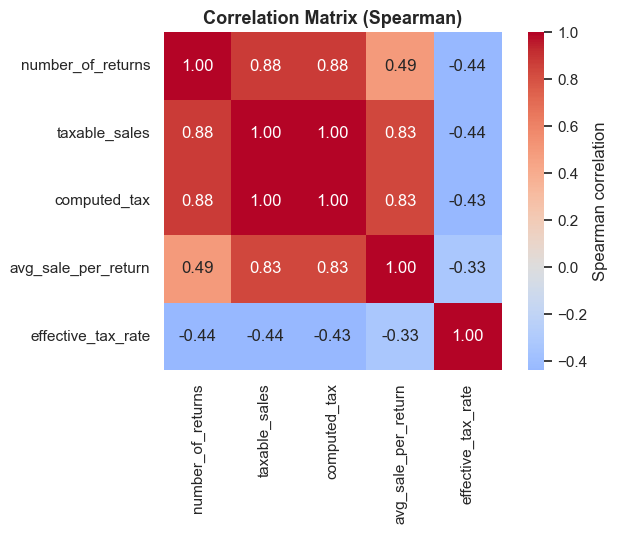

In [31]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'label': "Spearman correlation"})
ax.set_title('Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()

In [32]:
#Hypothesis Testing
#Test for normality.** Financial data of this kind is rarely normally distributed. 
#We confirm this with the Shapiro-Wilk test before selecting parametric vs. non-parametric tests.
sample = df['avg_sale_per_return'].dropna().sample(5000, random_state=RANDOM_STATE)

In [33]:
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk (raw, n=5000): W={shapiro_stat:.4f}, p={shapiro_p:.3g}")

Shapiro-Wilk (raw, n=5000): W=0.6431, p=0


In [34]:
log_sample = np.log1p(sample)
shapiro_stat_log, shapiro_p_log = stats.shapiro(log_sample)
print(f"Shapiro-Wilk (log1p, n=5000): W={shapiro_stat_log:.4f}, p={shapiro_p_log:.3g}")

Shapiro-Wilk (log1p, n=5000): W=0.9461, p=2.21e-39


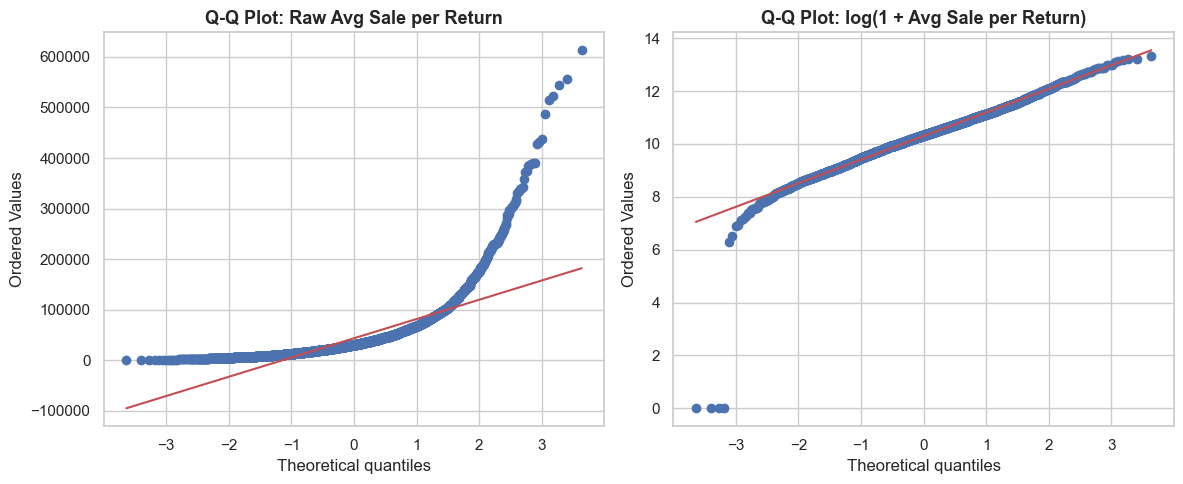

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(sample, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Raw Avg Sale per Return')
stats.probplot(log_sample, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: log(1 + Avg Sale per Return)')
plt.tight_layout()
plt.show()

Both raw and log-transformed distributions reject the null of normality (p < 0.001), though the log transform is far closer to normal. Given this, we use **non-parametric tests** (Mann-Whitney U, Kruskal-Wallis, Spearman correlation) as the primary tests, with parametric equivalents (Welch's t-test, Pearson) reported alongside for comparison — a common and defensible practice with large samples (t-tests are fairly robust to non-normality at n > 1000 per the Central Limit Theorem, but rank-based tests avoid the issue entirely).

In [ ]:
#Step 2 - Compare Urban vs. Rural counties.** Do urban counties show higher average sale per return than rural counties?
#H_0: The distributions of avg. sale per return are identical between Urban and Rural counties.
#$H_1: The distributions differ.
